# Where the backdoor lives in a ViT

`placement-walk.ipynb` is a ranking, and it ends on a fact that needs an explanation: PSBD-TM beats PSBD-RD on the patch triggers (BadNets and TaCT) and ties or trails on the global ones. This notebook explains it by following a trigger through a backdoored ViT, in 6 steps that each answer 1 question.

1. What each placement does to triggered and clean predictions (survival).
2. At what depth the trigger is written into the representation (the backdoor direction).
3. Whether that direction is what carries the backdoor (ablation).
4. Which tokens carry the decision at each depth (activation patching) and how attention moves the trigger to the class token (routing).
5. The causal test of why token masking separates patch triggers (masking the trigger's own tokens, recording PSBD-TM's masks, restricting PSBD-RD's dropout, keeping subsets of tokens visible).
6. Why a LayerNorm makes additive noise weaker than masking at the same position.

Every step reads a record already on disk, written by the experiment named in its section, so the notebook needs no GPU and runs in about 1 minute. An earlier version recomputed the direction and a steering test on the GPU for 1 model. Those are replaced here by the cached records that cover more models. The 8 source-mapped TaCT models and the diverged model are dropped from every record through `scripts.paper._common.excluded_folders`, as the paper's generators do, since neither is a trigger backdoor. The 1 exception is step 5, where the causal experiment reports the source-mapped models as a named contrast group, and the notebook shows them there under that name.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

import glob

from defenses.decision import ADAPTIVE_SHIFT_TARGET, PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT
from experiments.why_token_masking_works.measure import read_model_records, summarize
from scripts.paper._common import (
    attack_label,
    clearing_cells,
    excluded_folders,
    fmt,
    implanted_cells,
    load_coverage,
    load_json,
    word_list,
)
from scripts.paper._style import attack_color, legend_above

EXCLUDED = excluded_folders("results")
PATCH_ATTACKS = ("badnet_a2o", "tact")
print(f"{len(EXCLUDED)} checkpoints excluded as not a successful trigger backdoor: {sorted(EXCLUDED)}")

12 checkpoints excluded as not a successful trigger backdoor: ['vit_cifar100_tact_0_01', 'vit_cifar100_tact_0_05', 'vit_cifar100_tact_0_1', 'vit_cifar10_sig_0_1', 'vit_cifar10_tact_0_1', 'vit_cifar10_wanet_0_05', 'vit_gtsrb_tact_0_01', 'vit_gtsrb_tact_0_1', 'vit_gtsrb_wanet_0_1', 'vit_tiny_tact_0_01', 'vit_tiny_tact_0_05', 'vit_tiny_tact_0_1']


## 1. What each placement does to a triggered prediction

PSU is low when the perturbation leaves the prediction in place. So the first thing to measure is the share of predictions each placement changes, on clean images and on triggered images, at the rate the adaptive rule picked. `scripts/paper/mech_survival.py` reads this from `psbd_metrics.json`: the shift ratio of the validation, clean and backdoor splits at every swept rate, on the headline models carrying both placements at the adaptive rule. The notebook uses the generator's own `collect_records` and checks its means against `paper/tables/survival.macros.json`.

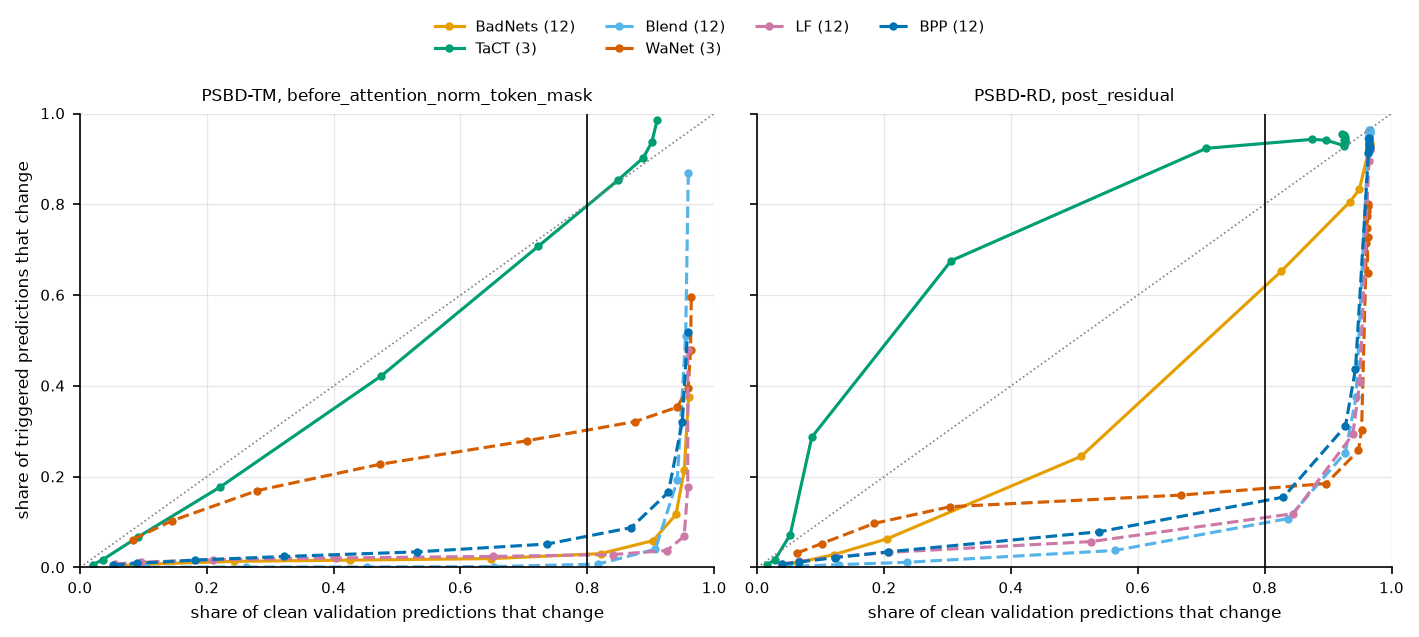

,models,PSBD-TM rate,PSBD-TM clean changed,PSBD-TM triggered changed,PSBD-TM AUROC,PSBD-RD rate,PSBD-RD clean changed,PSBD-RD triggered changed,PSBD-RD AUROC
attack,,,,,,,,,
BadNets,12,0.542,0.873,0.045,0.992,0.075,0.878,0.609,0.712
TaCT,3,0.633,0.836,0.796,0.962,0.090,0.874,0.943,0.563
Blend,12,0.517,0.870,0.040,0.978,0.073,0.881,0.136,0.971
WaNet,3,0.500,0.870,0.321,0.779,0.063,0.832,0.145,0.955
LF,12,0.533,0.878,0.033,0.980,0.073,0.874,0.144,0.974
BPP,12,0.583,0.853,0.104,0.948,0.073,0.867,0.195,0.945


In [2]:
from scripts.paper import mech_survival

records = mech_survival.collect_records("results")
grouped = mech_survival.by_attack(records)
assert str(len(records)) == macro("survival", "SurvivalModels")

names = mech_survival.PLACEMENT_NAMES
figure, axes = plt.subplots(1, 2, figsize=(9.5, 3.8), sharey=True)
for axis, key in zip(axes, mech_survival.PLACEMENTS):
    for attack, attack_records in grouped.items():
        curve = mech_survival.mean_curve(attack_records, key)
        axis.plot([p["validation"] for p in curve], [p["triggered"] for p in curve], marker="o", ms=3,
                  ls="-" if attack in PATCH_ATTACKS else "--", color=attack_color(attack), label=f"{attack_label(attack)} ({len(attack_records)})")
    axis.plot([0, 1], [0, 1], color="gray", lw=0.8, ls=":")
    axis.axvline(ADAPTIVE_SHIFT_TARGET, color="black", lw=0.8)
    axis.set_xlim(0, 1)
    axis.set_ylim(0, 1)
    axis.set_title(f"{names[key]}, {mech_survival.PLACEMENTS[key]}", fontsize=8)
    axis.set_xlabel("share of clean validation predictions that change")
axes[0].set_ylabel("share of triggered predictions that change")
figure.tight_layout()
legend_above(figure, list(axes), columns=4)
plt.show()

survival_rows = []
for attack, attack_records in grouped.items():
    row = {"attack": attack_label(attack), "models": len(attack_records)}
    for key, name in names.items():
        row[f"{name} rate"] = mech_survival.adaptive_mean(attack_records, key, "rate")
        row[f"{name} clean changed"] = mech_survival.adaptive_mean(attack_records, key, "clean")
        row[f"{name} triggered changed"] = mech_survival.adaptive_mean(attack_records, key, "triggered")
        row[f"{name} AUROC"] = mech_survival.adaptive_mean(attack_records, key, "auroc")
        prefix = "SurvivalTm" if name == "PSBD-TM" else "SurvivalRd"
        token = "BadnetATwoo" if attack == "badnet_a2o" else attack.capitalize()
        assert fmt(row[f"{name} triggered changed"], places=2) == macro("survival", f"{prefix}{token}Triggered"), (attack, name)
    survival_rows.append(row)
survival = pd.DataFrame(survival_rows).set_index("attack")
survival_all = {name: {field: mech_survival.adaptive_mean(records, key, field) for field in ("rate", "clean", "triggered")} for key, name in names.items()}
global_rows = [attack_label(a) for a in ("blend", "lf", "bpp")]
assert (survival.loc[global_rows, "PSBD-TM triggered changed"] < 0.15).all(), "the reading says Blend, LF and BPP survive PSBD-TM"
survival.round(3)

In [3]:
display(Markdown(rf"""
Each line is 1 attack, averaged over its panel models at every swept rate, with the clean validation shift ratio on the x axis and the triggered shift ratio on the y axis. The vertical line is the adaptive target, so where a line crosses it is where the rule reads. A line near the floor means triggered predictions survive the perturbation that moves {ADAPTIVE_SHIFT_TARGET:.0%} of clean ones, which is exactly what makes PSU separate. On the left, PSBD-TM changes {survival.loc["BadNets", "PSBD-TM triggered changed"]:.2f} of BadNets triggered predictions at the adaptive rate against {survival_all["PSBD-TM"]["clean"]:.2f} of clean predictions, and Blend, LF and BPP change at most {survival.loc[global_rows, "PSBD-TM triggered changed"].max():.2f}. On the right, PSBD-RD changes {survival.loc["BadNets", "PSBD-RD triggered changed"]:.2f} of BadNets triggered predictions, while the global triggers change at most {survival.loc[global_rows, "PSBD-RD triggered changed"].max():.2f}. The same clean shift is reached at very different rates, {survival_all["PSBD-TM"]["rate"]:.2f} for PSBD-TM and {survival_all["PSBD-RD"]["rate"]:.2f} for PSBD-RD on average (`\SurvivalTmRate`, `\SurvivalRdRate`).

The {survival.loc["TaCT", "models"]} trigger-conditional TaCT models are the exception on the left. Their triggered predictions change often under PSBD-TM ({survival.loc["TaCT", "PSBD-TM triggered changed"]:.2f}) and PSBD-TM still scores {survival.loc["TaCT", "PSBD-TM AUROC"]:.3f} on them, because the clean source-class predictions change even more. The figure does not say why a patch trigger survives token masking and not residual dropout, which the rest of the notebook works out.
"""))


Each line is 1 attack, averaged over its panel models at every swept rate, with the clean validation shift ratio on the x axis and the triggered shift ratio on the y axis. The vertical line is the adaptive target, so where a line crosses it is where the rule reads. A line near the floor means triggered predictions survive the perturbation that moves 80% of clean ones, which is exactly what makes PSU separate. On the left, PSBD-TM changes 0.04 of BadNets triggered predictions at the adaptive rate against 0.87 of clean predictions, and Blend, LF and BPP change at most 0.10. On the right, PSBD-RD changes 0.61 of BadNets triggered predictions, while the global triggers change at most 0.20. The same clean shift is reached at very different rates, 0.55 for PSBD-TM and 0.07 for PSBD-RD on average (`\SurvivalTmRate`, `\SurvivalRdRate`).

The 3 trigger-conditional TaCT models are the exception on the left. Their triggered predictions change often under PSBD-TM (0.80) and PSBD-TM still scores 0.962 on them, because the clean source-class predictions change even more. The figure does not say why a patch trigger survives token masking and not residual dropout, which the rest of the notebook works out.


## 2. The depth at which the trigger is written

For a layer $\ell$, the **backdoor direction** is the mean difference between a triggered image's class-token activation and its clean twin's, $d_\ell = \frac{1}{n}\sum_i \left(h_\ell(\tilde x_i) - h_\ell(x_i)\right)$, where $h_\ell$ is the class-token vector after block $\ell$ and $\tilde x_i$ the triggered copy of $x_i$ (`analysis.direction.backdoor_direction`). Its norm relative to the mean activation norm says how strongly the trigger has been written into the class token by that depth. **CKA** (centered kernel alignment, debiased, `analysis.cka`) compares the clean and triggered representations as a whole, with 1 meaning identical up to rotation and scale. `scripts/paper/run_tac_layers.py` measured both at every layer, and `results/_experiments/tac_layers/tac_layers.json` holds the record, whose size the cell prints.

15 models kept of 18, dropped as excluded: ['vit_cifar100_tact_0_1', 'vit_gtsrb_tact_0_1', 'vit_gtsrb_wanet_0_1']
500 paired images per model, precision float32, commit ae3101e9


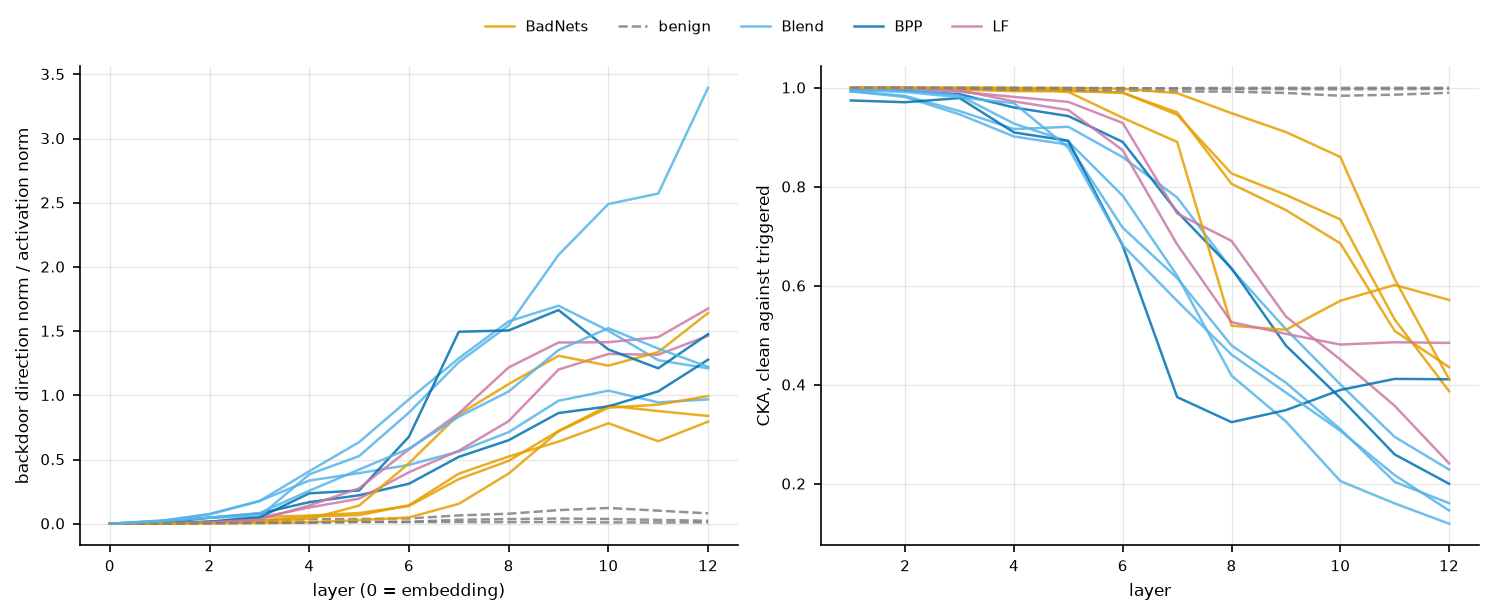

mean onset layer, macros from paper/tables/tac_layers.macros.json: BadNets 8.0 | Blend 7.0 | earliest blend | latest badnet_a2o


In [4]:
tac_record = load_json("results/_experiments/tac_layers/tac_layers.json")
tac_rows = [
    {"folder": r["folder"], "attack": r["attack"], "dataset": r["dataset"], "layer": layer["layer"],
     "rel_direction_norm": layer["rel_direction_norm"], "cka": layer["cka"]}
    for r in tac_record["records"]
    if r["folder"] not in EXCLUDED
    for layer in r["layers"]
]
tac = pd.DataFrame(tac_rows)
dropped = sorted({r["folder"] for r in tac_record["records"]} & EXCLUDED)
print(f"{tac['folder'].nunique()} models kept of {len(tac_record['records'])}, dropped as excluded: {dropped}")
print(f"{tac_record['samples']} paired images per model, precision {tac_record['precision']}, commit {tac_record['git_commit'][:8]}")

figure, (norm_axis, cka_axis) = plt.subplots(1, 2, figsize=(10.0, 3.8))
for folder, rows in tac.groupby("folder"):
    attack = rows["attack"].iloc[0]
    style = dict(color=attack_color(attack), lw=1.2, ls="--" if attack == "benign" else "-", alpha=0.85)
    norm_axis.plot(rows["layer"], rows["rel_direction_norm"], label=attack_label(attack), **style)
    # CKA at the embedding layer is recorded as 0, a degenerate value, so it is not drawn.
    cka_axis.plot(rows["layer"][rows["layer"] > 0], rows["cka"][rows["layer"] > 0], **style)
norm_axis.set_xlabel("layer (0 = embedding)")
norm_axis.set_ylabel("backdoor direction norm / activation norm")
cka_axis.set_xlabel("layer")
cka_axis.set_ylabel("CKA, clean against triggered")
figure.tight_layout()
legend_above(figure, [norm_axis], columns=6)
plt.show()
print("mean onset layer, macros from paper/tables/tac_layers.macros.json:",
      "BadNets", macro("tac_layers", "TacLayersBadnetOnset"), "| Blend", macro("tac_layers", "TacLayersBlendOnset"),
      "| earliest", macro("tac_layers", "TacLayersEarliestOnsetAttack"), "| latest", macro("tac_layers", "TacLayersLatestOnsetAttack"))

In [5]:
display(Markdown(rf"""
The dashed benign models, probed with the same trigger they never learned, keep the relative direction norm at most {macro("tac_layers", "TacLayersBenignPeakMax")} at every layer (`\TacLayersBenignPeakMax`) and CKA near 1. Every backdoored model stays low through the first blocks and climbs in the second half of the network, and CKA falls in the same layers. The trigger is not present in the class token from the start. It is written there in the middle and late blocks, with a mean onset layer of {macro("tac_layers", "TacLayersBadnetOnset")} for BadNets and {macro("tac_layers", "TacLayersBlendOnset")} for Blend (`\TacLayersBadnetOnset`, `\TacLayersBlendOnset`). The figure reads the class token only, so it does not show where the trigger's content sits before it reaches the class token, and it does not show that the direction is causal. The next 2 steps take those in turn.
"""))


The dashed benign models, probed with the same trigger they never learned, keep the relative direction norm at most 0.12 at every layer (`\TacLayersBenignPeakMax`) and CKA near 1. Every backdoored model stays low through the first blocks and climbs in the second half of the network, and CKA falls in the same layers. The trigger is not present in the class token from the start. It is written there in the middle and late blocks, with a mean onset layer of 8.0 for BadNets and 7.0 for Blend (`\TacLayersBadnetOnset`, `\TacLayersBlendOnset`). The figure reads the class token only, so it does not show where the trigger's content sits before it reaches the class token, and it does not show that the direction is causal. The next 2 steps take those in turn.


## 3. The direction carries the backdoor

A mean difference could be a side effect rather than the mechanism. The ablation test removes the rank-1 direction from the residual stream at the peak layer and measures the ASR that remains, against 3 controls: 2 random directions of the same norm, the top 20 coordinates of the direction zeroed, and 20 random coordinates zeroed. `experiments/backdoor_neurons/` ran it on CIFAR-10 models, and `results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json` holds it. The SAM-trained twins in the record are shown beside the plain ones.

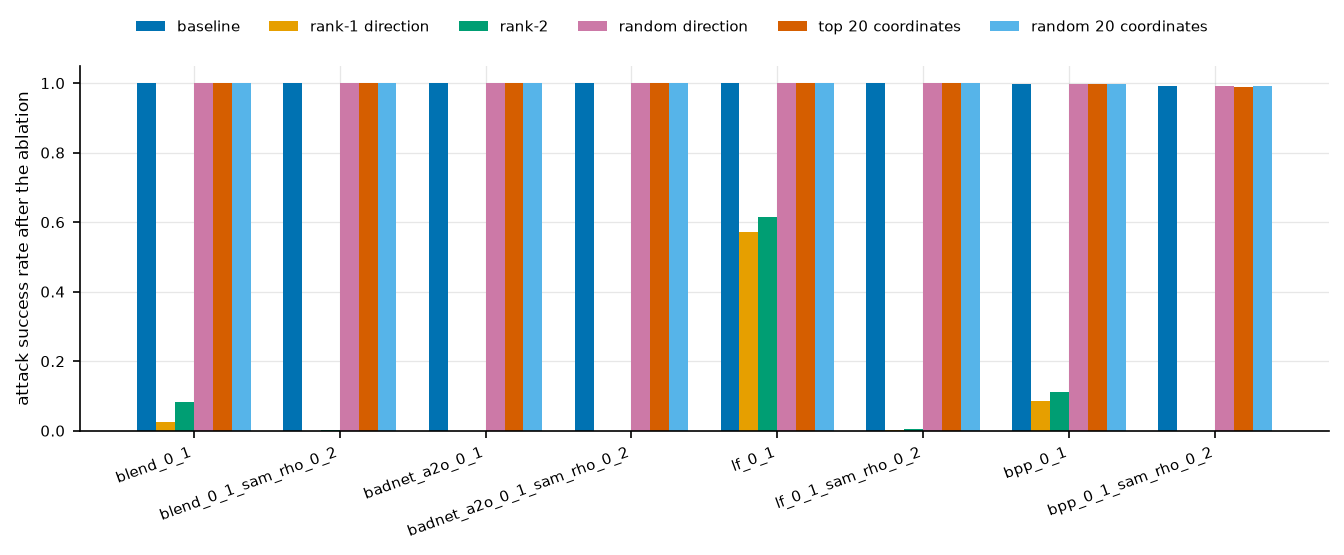

,attack,baseline,rank-1 direction,rank-2,random direction,top 20 coordinates,random 20 coordinates,"clean accuracy lost, rank-1"
model,,,,,,,,
blend_0_1,blend,1.000,0.026,0.083,1.000,1.000,1.000,0.030
blend_0_1_sam_rho_0_2,blend,1.000,0.000,0.002,1.000,1.000,1.000,0.052
badnet_a2o_0_1,badnet_a2o,1.000,0.000,0.000,1.000,1.000,1.000,0.038
badnet_a2o_0_1_sam_rho_0_2,badnet_a2o,1.000,0.000,0.000,1.000,1.000,1.000,0.078
lf_0_1,lf,1.000,0.572,0.615,1.000,1.000,1.000,0.002
lf_0_1_sam_rho_0_2,lf,1.000,0.002,0.004,1.000,1.000,1.000,0.066
bpp_0_1,bpp,0.998,0.085,0.111,0.998,0.998,0.998,0.016
bpp_0_1_sam_rho_0_2,bpp,0.993,0.000,0.000,0.993,0.989,0.993,0.046


In [6]:
ablation = load_json("results/_experiments/backdoor_neurons/backdoor_neuron_ablation.json")
variants = {"baseline": None, "rank-1 direction": "direction", "rank-2": "rank_2", "random direction": "random_dir_0",
            "top 20 coordinates": "top_20", "random 20 coordinates": "random_20"}
ablation_rows = []
for record in ablation:
    row = {"model": record["folder_name"].removeprefix("vit_cifar10_"), "attack": record["attack"]}
    for label, key in variants.items():
        row[label] = record["baseline"]["asr"] if key is None else record["ablated"][key]["asr"]
    row["clean accuracy lost, rank-1"] = record["baseline"]["clean_accuracy"] - record["ablated"]["direction"]["clean_accuracy"]
    ablation_rows.append(row)
ablation_frame = pd.DataFrame(ablation_rows).set_index("model")

figure, axis = plt.subplots(figsize=(9.0, 3.4))
width = 0.13
positions = np.arange(len(ablation_frame))  # (models,)
for offset, label in enumerate(variants):
    axis.bar(positions + (offset - 2.5) * width, ablation_frame[label], width=width, label=label)
axis.set_xticks(positions, labels=ablation_frame.index, rotation=20, ha="right", fontsize=7)
axis.set_ylabel("attack success rate after the ablation")
figure.tight_layout()
legend_above(figure, [axis], columns=6)
plt.show()

plain = ablation_frame[~ablation_frame.index.str.contains("sam")]
plain_by_attack = plain.set_index("attack")
assert fmt(plain["rank-1 direction"].min()) == macro("direction", "AblationDirectionMinAsr")
assert fmt(plain["rank-1 direction"].max()) == macro("direction", "AblationDirectionMaxAsr")
ablation_frame.round(3)

In [7]:
display(Markdown(rf"""
On the {len(plain)} plain models, removing the single direction takes ASR from about 1 to {plain_by_attack.loc["badnet_a2o", "rank-1 direction"]:.2f} on BadNets, {plain_by_attack.loc["blend", "rank-1 direction"]:.2f} on Blend and {plain_by_attack.loc["bpp", "rank-1 direction"]:.2f} on BPP, at a clean-accuracy cost of at most {plain["clean accuracy lost, rank-1"].max():.3f}, while a random direction of the same norm leaves ASR at least {ablation_frame["random direction"].min():.2f} and zeroing 20 coordinates, top or random, at least {ablation_frame[["top 20 coordinates", "random 20 coordinates"]].min().min():.2f}. LF is the partial exception, {plain_by_attack.loc["lf", "rank-1 direction"]:.3f} left after the rank-1 removal on the plain model (`\AblationDirectionMaxAsr`). So on these models the backdoor is a direction in the residual stream, not a handful of neurons, which is why the PSBD paper's neuron-bias account is not the mechanism here. The record covers {len(plain)} CIFAR-10 models and their SAM twins, and it says nothing about which tokens carry the trigger before the class token reads it.
"""))


On the 4 plain models, removing the single direction takes ASR from about 1 to 0.00 on BadNets, 0.03 on Blend and 0.08 on BPP, at a clean-accuracy cost of at most 0.038, while a random direction of the same norm leaves ASR at least 0.99 and zeroing 20 coordinates, top or random, at least 0.99. LF is the partial exception, 0.572 left after the rank-1 removal on the plain model (`\AblationDirectionMaxAsr`). So on these models the backdoor is a direction in the residual stream, not a handful of neurons, which is why the PSBD paper's neuron-bias account is not the mechanism here. The record covers 4 CIFAR-10 models and their SAM twins, and it says nothing about which tokens carry the trigger before the class token reads it.


## 4. Which tokens carry the decision, and when the class token reads them

**Activation patching** runs the clean image and the triggered image, overwrites a group of tokens in the triggered run with their clean values at 1 block, and measures the recovery, the share of the clean prediction that comes back (1 means the clean answer is fully restored). 3 groups are patched: the trigger's own tokens, the class token and a random group of the trigger's size as the null. `results/<folder>/activation_patching.json` carries it for every successful model, and `scripts/paper/mech_activation_patching.py` averages it per attack at the residual-stream site.

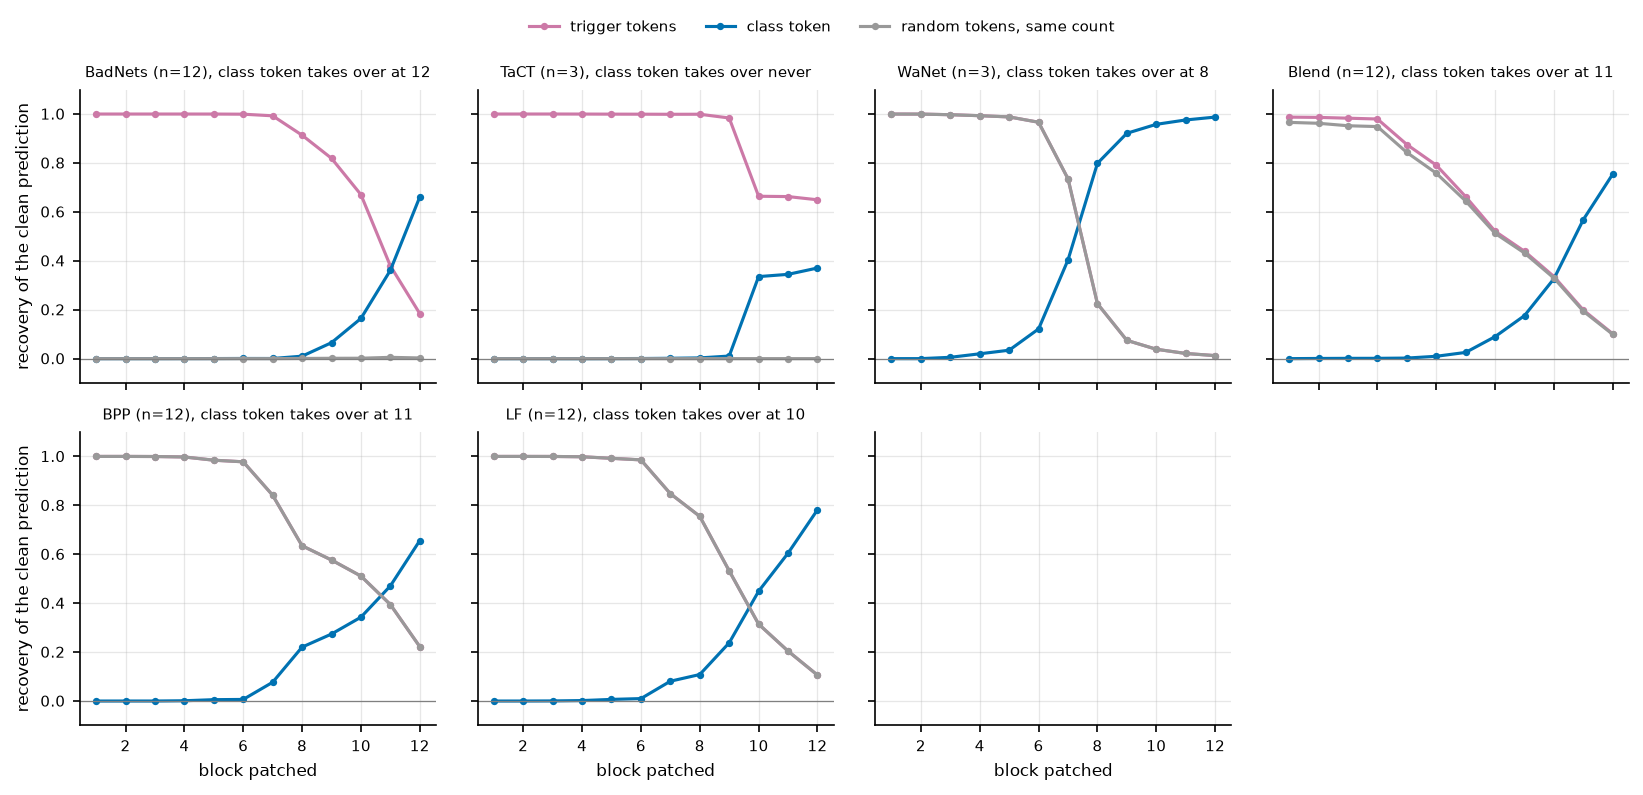

54 successful models carry activation_patching.json


In [8]:
from scripts.paper import mech_activation_patching as patching

coverage = load_coverage("results")
patch_records = {}
for cell in clearing_cells(coverage):
    record = load_json(f"results/{cell['folder_name']}/activation_patching.json")
    if record is not None:
        patch_records.setdefault(cell["attack"], []).append(record)
patch_count = sum(len(v) for v in patch_records.values())
assert str(patch_count) == macro("activation_patching", "PatchingCells")

attacks = [a for a in ("badnet_a2o", "tact", "wanet", "sig", "blend", "bpp", "lf") if a in patch_records]
curves = {attack: patching.mean_curves(patch_records[attack]) for attack in attacks}
figure, axes = plt.subplots(2, 4, figsize=(11.0, 5.0), sharex=True, sharey=True)
for axis, attack in zip(axes.flat, attacks):
    for group, color in zip(patching.GROUPS, ("#CC79A7", "#0072B2", "#999999")):
        axis.plot(curves[attack]["layers"], curves[attack][group], marker="o", ms=2.5, color=color, label=patching.GROUP_LABELS[group])
    crossover = patching.crossover_layer(curves[attack])
    takeover = "never" if crossover is None else f"at {crossover}"
    axis.set_title(f"{attack_label(attack)} (n={len(patch_records[attack])}), class token takes over {takeover}", fontsize=7)
    axis.axhline(0, color="gray", lw=0.6)
    axis.set_ylim(-0.1, 1.1)
axes.flat[-1].axis("off")
for axis in axes[1]:
    axis.set_xlabel("block patched")
for axis in axes[:, 0]:
    axis.set_ylabel("recovery of the clean prediction")
legend_above(figure, list(axes.flat[:len(attacks)]), columns=3)
figure.tight_layout()
plt.show()
print(f"{patch_count} successful models carry activation_patching.json")
badnet_last_full = patching.last_full_layer(curves["badnet_a2o"])
badnet_crossover = patching.crossover_layer(curves["badnet_a2o"])
tact_last_full = patching.last_full_layer(curves["tact"])
tact_crossover = patching.crossover_layer(curves["tact"])
global_attacks = [a for a in attacks if a not in PATCH_ATTACKS]
global_crossovers = [patching.crossover_layer(curves[a]) for a in global_attacks]
global_token_counts = sorted({r["n_trigger_tokens"] for a in global_attacks for r in patch_records[a]})
assert str(badnet_last_full) == macro("activation_patching", "PatchingBadnetLastFull")
assert str(badnet_crossover) == macro("activation_patching", "PatchingBadnetCrossover")

In [9]:
display(Markdown(rf"""
For BadNets, patching the trigger's own tokens alone restores at least half the clean prediction at every block up to {badnet_last_full} (`\PatchingBadnetLastFull`), and the class token recovers nothing until the last blocks, taking over only at block {badnet_crossover} (`\PatchingBadnetCrossover`). Until then the trigger's evidence sits in the trigger's own tokens. On TaCT the trigger tokens keep at least half the decision through block {tact_last_full} and the class token {"never overtakes them" if tact_crossover is None else f"overtakes them at block {tact_crossover}"}. For a global trigger the "trigger tokens" are every patch the trigger changed, {min(global_token_counts)} to {max(global_token_counts)} of the 196, so the pink curve is hidden under the gray random group of the same size, and patching them is patching almost the whole image. Their curves show when the class token takes the decision over (blocks {min(global_crossovers)} to {max(global_crossovers)}) rather than where the trigger sits. The random group recovers nothing on the patch attacks, the null. The figure does not show how the trigger's content moves to the class token, which the routing record measures.
"""))


For BadNets, patching the trigger's own tokens alone restores at least half the clean prediction at every block up to 10 (`\PatchingBadnetLastFull`), and the class token recovers nothing until the last blocks, taking over only at block 12 (`\PatchingBadnetCrossover`). Until then the trigger's evidence sits in the trigger's own tokens. On TaCT the trigger tokens keep at least half the decision through block 12 and the class token never overtakes them. For a global trigger the "trigger tokens" are every patch the trigger changed, 189 to 196 of the 196, so the pink curve is hidden under the gray random group of the same size, and patching them is patching almost the whole image. Their curves show when the class token takes the decision over (blocks 8 to 11) rather than where the trigger sits. The random group recovers nothing on the patch attacks, the null. The figure does not show how the trigger's content moves to the class token, which the routing record measures.


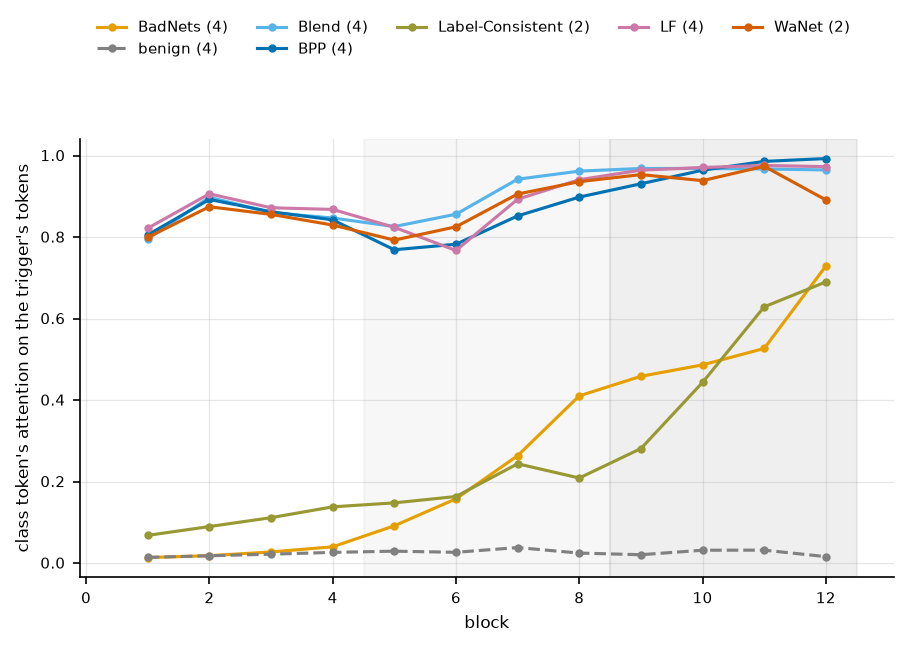

BadNets: class-token attention on the trigger tokens, blocks 9 to 12: 0.550, benign under the same trigger: 0.025
excluded folders removed by mech_routing.all_folders: ['vit_cifar100_tact_0_1', 'vit_cifar10_sig_0_1', 'vit_cifar10_tact_0_1', 'vit_gtsrb_tact_0_1', 'vit_gtsrb_wanet_0_1', 'vit_tiny_tact_0_1']


In [10]:
from scripts.paper import mech_routing as routing

routing_records = routing.records_by_attack("results", "cls_routing.json", routing.all_folders("results", "cls_routing.json"))
figure, axis = plt.subplots(figsize=(7.0, 3.8))
for attack, attack_records in routing_records.items():
    curve = routing.layer_curve(attack_records, "weight_backdoor")
    axis.plot(range(1, len(curve) + 1), curve, marker="o", ms=3, color=attack_color(attack),
              ls="--" if attack == "benign" else "-", label=f"{attack_label(attack)} ({len(attack_records)})")
for band, shade in ((routing.EARLY_LAYERS, 0.0), (routing.ROUTING_LAYERS, 0.06), (routing.LATE_LAYERS, 0.12)):
    axis.axvspan(band[0] - 0.5, band[-1] + 0.5, color="gray", alpha=shade)
axis.set_xlabel("block")
axis.set_ylabel("class token's attention on the trigger's tokens")
legend_above(figure, [axis], columns=5)
plt.show()

badnet_late = routing.layer_mean(routing_records["badnet_a2o"], "weight_backdoor", routing.LATE_LAYERS)
benign_late = routing.layer_mean(routing_records["benign"], "weight_backdoor", routing.LATE_LAYERS)
assert fmt(badnet_late) == macro("routing", "RoutingBadnetClsLate")
assert fmt(benign_late) == macro("routing", "RoutingBenignClsLate")
badnet_early = routing.layer_mean(routing_records["badnet_a2o"], "weight_backdoor", routing.EARLY_LAYERS)
badnet_middle = routing.layer_mean(routing_records["badnet_a2o"], "weight_backdoor", routing.ROUTING_LAYERS)
badnet_share = routing_records["badnet_a2o"][0]["trigger_token_share"]
blend_share = routing_records["blend"][0]["trigger_token_share"]
print(f"BadNets: class-token attention on the trigger tokens, blocks 9 to 12: {badnet_late:.3f}, benign under the same trigger: {benign_late:.3f}")
print("excluded folders removed by mech_routing.all_folders:", sorted(f for f in EXCLUDED if glob.glob(f"results/{f}/cls_routing.json")))

In [11]:
display(Markdown(rf"""
`results/<folder>/cls_routing.json` records, per block, the share of the class token's attention that falls on the trigger's tokens, at the highest panel rate of each attack and for the benign references. On BadNets the share is {badnet_early:.3f} in blocks 1 to 4, {badnet_middle:.3f} in 5 to 8 and {badnet_late:.3f} in 9 to 12 (`\RoutingBadnetClsEarly`, `\RoutingBadnetClsRouting`, `\RoutingBadnetClsLate`), for trigger tokens that are {badnet_share:.1%} of the patches. The benign models, probed with the same trigger, stay at {benign_late:.3f} in the late blocks. For the global triggers the "trigger tokens" are nearly every patch (the record's `trigger_token_share` is {blend_share:.2f} for Blend), so their curves sit near 1 throughout and say nothing about routing. The Label-Consistent models ({len(routing_records.get("lc", []))}, outside the ViT headline panel but kept by `mech_routing.all_folders`) follow BadNets, since their trigger is a patch too. Attention is the only operation that moves content between tokens, so this is the route: the class token reads the patch trigger in the late blocks. What the routing does not show is whether the late read is necessary, the causal test that follows.
"""))


`results/<folder>/cls_routing.json` records, per block, the share of the class token's attention that falls on the trigger's tokens, at the highest panel rate of each attack and for the benign references. On BadNets the share is 0.025 in blocks 1 to 4, 0.231 in 5 to 8 and 0.550 in 9 to 12 (`\RoutingBadnetClsEarly`, `\RoutingBadnetClsRouting`, `\RoutingBadnetClsLate`), for trigger tokens that are 2.0% of the patches. The benign models, probed with the same trigger, stay at 0.025 in the late blocks. For the global triggers the "trigger tokens" are nearly every patch (the record's `trigger_token_share` is 0.96 for Blend), so their curves sit near 1 throughout and say nothing about routing. The Label-Consistent models (2, outside the ViT headline panel but kept by `mech_routing.all_folders`) follow BadNets, since their trigger is a patch too. Attention is the only operation that moves content between tokens, so this is the route: the class token reads the patch trigger in the late blocks. What the routing does not show is whether the late read is necessary, the causal test that follows.


## 5. The causal test of why token masking works

`experiments/why_token_masking_works/` tested 4 hypotheses with deterministic and recorded masks on the panel models, and `results/_experiments/why_token_masking_works/<folder>.json` holds 1 record per model (`scripts/paper/mech_causal.py` summarizes the panel models among them into the `\Causal*` macros, and the cell below summarizes the same records with the source-mapped TaCT models kept as a contrast). The models are grouped as BadNets, trigger-conditional TaCT and, kept here as a contrast, source-mapped TaCT, whose triggered predictions are carried by the source class rather than the trigger. **Triggered kept** is the share of triggered images still sent to the target among those the unperturbed model sends there, and **clean kept** the share of clean images keeping their unperturbed class.

Part A masks the trigger's own tokens at the attention input, deterministically, in chosen blocks only, with the class token never masked.

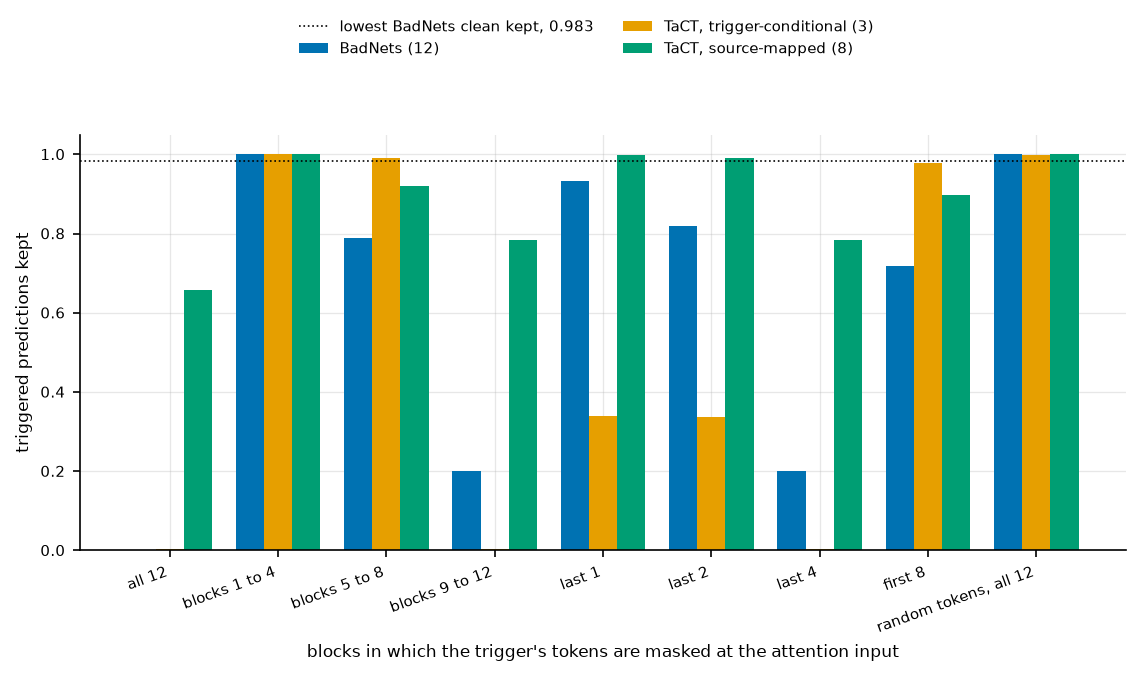

,BadNets,"TaCT, trigger-conditional","TaCT, source-mapped"
all 12,0.002,0.004,0.658
blocks 1 to 4,1.000,1.000,1.000
blocks 5 to 8,0.788,0.992,0.920
blocks 9 to 12,0.200,0.004,0.783
last 1,0.934,0.339,0.998
last 2,0.820,0.337,0.991
last 4,0.200,0.004,0.783
first 8,0.719,0.978,0.897
"random tokens, all 12",1.000,0.999,1.000


In [12]:
# The paper's Causal* macros summarize the panel models only
# (scripts/paper/mech_causal.py). Here the source-mapped TaCT models stay in as
# the contrast group, and the models the clean-accuracy bar removes are dropped
# as in the paper, with the experiment's own summarize.
failing_bar = {cell["folder_name"] for cell in implanted_cells(load_coverage("results")) if not cell["successful_2pt"]}
causal = summarize([record for record in read_model_records("results/_experiments/why_token_masking_works") if record["folder"] not in failing_bar])
masking = causal["deterministic_masking"]
rows_shown = ["all_12", "blocks_1_4", "blocks_5_8", "blocks_9_12", "last_1", "last_2", "last_4", "first_8", "random_all_12"]
row_labels = ["all 12", "blocks 1 to 4", "blocks 5 to 8", "blocks 9 to 12", "last 1", "last 2", "last 4", "first 8", "random tokens, all 12"]
groups = {"badnet_a2o": "BadNets", "tact_trigger_conditional": "TaCT, trigger-conditional", "tact_source_mapped": "TaCT, source-mapped"}

figure, axis = plt.subplots(figsize=(9.0, 3.6))
width = 0.26
positions = np.arange(len(rows_shown))  # (rows,)
for offset, (group, label) in enumerate(groups.items()):
    kept = [masking[group][row]["triggered_kept"] for row in rows_shown]
    axis.bar(positions + (offset - 1) * width, kept, width=width, label=f"{label} ({masking[group]['all_12']['models']})")
clean_min = min(masking["badnet_a2o"][row]["clean_kept"] for row in rows_shown)
axis.axhline(clean_min, color="black", lw=0.8, ls=":", label=f"lowest BadNets clean kept, {clean_min:.3f}")
axis.set_xticks(positions, labels=row_labels, rotation=20, ha="right")
axis.set_ylabel("triggered predictions kept")
axis.set_xlabel("blocks in which the trigger's tokens are masked at the attention input")
legend_above(figure, [axis], columns=2)
plt.show()

assert fmt(masking["badnet_a2o"]["all_12"]["triggered_kept"]) == macro("causal", "CausalMaskAllOneTwo")
assert fmt(masking["badnet_a2o"]["blocks_1_4"]["triggered_kept"]) == macro("causal", "CausalMaskBlocksOneFour")
assert fmt(masking["badnet_a2o"]["blocks_9_12"]["triggered_kept"]) == macro("causal", "CausalMaskBlocksNineOneTwo")
assert fmt(masking["badnet_a2o"]["random_all_12"]["triggered_kept"]) == macro("causal", "CausalMaskRandomAllOneTwo")
clean_kept_range = [min(masking[g][r]["clean_kept"] for g in ("badnet_a2o", "tact_trigger_conditional") for r in rows_shown), max(masking[g][r]["clean_kept"] for g in ("badnet_a2o", "tact_trigger_conditional") for r in rows_shown)]
bad = masking["badnet_a2o"]
pairs_per_model = causal["per_model"][0]["pairs"]
pd.DataFrame({label: [masking[group][row]["triggered_kept"] for row in rows_shown] for group, label in groups.items()}, index=row_labels).round(3)

In [13]:
display(Markdown(rf"""
The record holds {pairs_per_model} image pairs per model over {causal["models_by_group"]["badnet_a2o"]} BadNets, {causal["models_by_group"]["tact_trigger_conditional"]} trigger-conditional TaCT and {causal["models_by_group"]["tact_source_mapped"]} source-mapped TaCT models. Masking the BadNets trigger's tokens in all 12 blocks leaves {bad["all_12"]["triggered_kept"]:.3f} of triggered predictions, and masking as many random tokens leaves {bad["random_all_12"]["triggered_kept"]:.3f}, so the trigger's tokens are where the backdoor enters. Masking them in blocks 1 to 4 leaves {bad["blocks_1_4"]["triggered_kept"]:.3f}, because a token hidden from attention keeps its content in the residual stream and delivers it later. Masking them only in blocks 9 to 12 leaves {bad["blocks_9_12"]["triggered_kept"]:.3f} and in the last block alone {bad["last_1"]["triggered_kept"]:.3f}, so the class token reads the trigger over blocks 5 to 12 with most of the weight in 9 to 12. The trigger-conditional TaCT models keep {masking["tact_trigger_conditional"]["last_4"]["triggered_kept"]:.3f} with the last 4 blocks masked, so they are read only in the last few blocks, and the source-mapped TaCT models keep {masking["tact_source_mapped"]["all_12"]["triggered_kept"]:.3f} even with every trigger token masked, since their prediction does not need the trigger. Clean predictions stay between {clean_kept_range[0]:.3f} and {clean_kept_range[1]:.3f} in every row of the 2 trigger backdoors. What this does not show is what PSBD-TM's random masks do, part B.

Part B runs PSBD-TM at each model's adaptive rate and records, per pass and image, in how many of blocks 9 to 12 every trigger token was masked.
"""))


The record holds 256 image pairs per model over 12 BadNets, 3 trigger-conditional TaCT and 8 source-mapped TaCT models. Masking the BadNets trigger's tokens in all 12 blocks leaves 0.002 of triggered predictions, and masking as many random tokens leaves 1.000, so the trigger's tokens are where the backdoor enters. Masking them in blocks 1 to 4 leaves 1.000, because a token hidden from attention keeps its content in the residual stream and delivers it later. Masking them only in blocks 9 to 12 leaves 0.200 and in the last block alone 0.934, so the class token reads the trigger over blocks 5 to 12 with most of the weight in 9 to 12. The trigger-conditional TaCT models keep 0.004 with the last 4 blocks masked, so they are read only in the last few blocks, and the source-mapped TaCT models keep 0.658 even with every trigger token masked, since their prediction does not need the trigger. Clean predictions stay between 0.983 and 1.000 in every row of the 2 trigger backdoors. What this does not show is what PSBD-TM's random masks do, part B.

Part B runs PSBD-TM at each model's adaptive rate and records, per pass and image, in how many of blocks 9 to 12 every trigger token was masked.


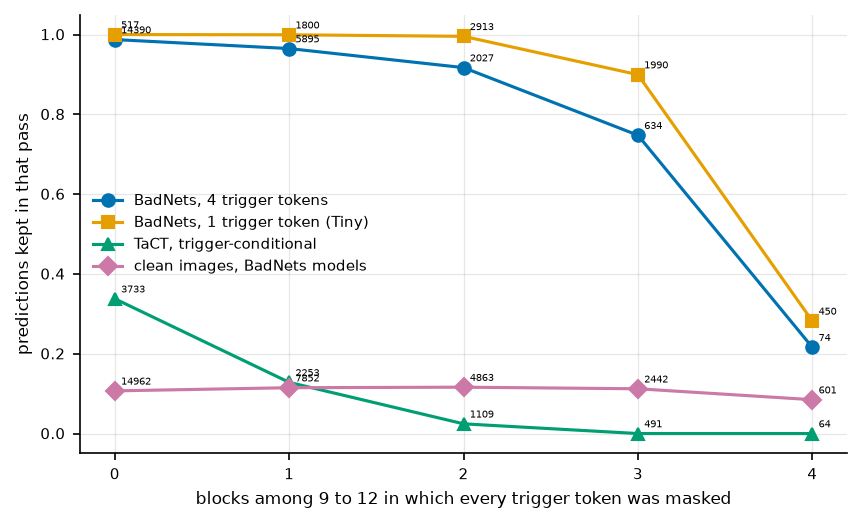

BadNets under PSBD-TM: triggered kept 0.957, clean kept 0.110 per pass


In [14]:
stochastic = causal["stochastic_token_mask"]
by_tokens = causal["stochastic_token_mask_by_trigger_tokens"]
series = {
    "BadNets, 4 trigger tokens": by_tokens["badnet_a2o_4_tokens"]["triggered"]["late_all"],
    "BadNets, 1 trigger token (Tiny)": by_tokens["badnet_a2o_1_tokens"]["triggered"]["late_all"],
    "TaCT, trigger-conditional": stochastic["tact_trigger_conditional"]["triggered"]["late_all"],
    "clean images, BadNets models": stochastic["badnet_a2o"]["clean"]["late_all"],
}
figure, axis = plt.subplots(figsize=(6.6, 3.8))
for (label, curve), marker in zip(series.items(), ("o", "s", "^", "D")):
    counts = sorted(curve, key=int)
    axis.plot([int(c) for c in counts], [curve[c]["kept"] for c in counts], marker=marker, label=label)
    for c in counts:
        axis.annotate(str(curve[c]["n"]), (int(c), curve[c]["kept"]), fontsize=5, xytext=(3, 3), textcoords="offset points")
axis.set_xticks(range(5))
axis.set_xlabel("blocks among 9 to 12 in which every trigger token was masked")
axis.set_ylabel("predictions kept in that pass")
axis.legend()
plt.show()

overall = stochastic["badnet_a2o"]["overall"]
assert fmt(overall["triggered_kept"]) == macro("causal", "CausalTmTriggeredKept")
assert fmt(overall["clean_kept"]) == macro("causal", "CausalTmCleanKept")
print(f"BadNets under PSBD-TM: triggered kept {overall['triggered_kept']:.3f}, clean kept {overall['clean_kept']:.3f} per pass")
four_token = by_tokens["badnet_a2o_4_tokens"]["triggered"]["late_all"]
one_token = by_tokens["badnet_a2o_1_tokens"]["triggered"]["late_all"]
four_token_passes = sum(v["n"] for v in four_token.values())
one_token_passes = sum(v["n"] for v in one_token.values())
tm_rates = [m["tm_rate"] for m in causal["per_model"] if m["group"] == "badnet_a2o"]
clean_curve = stochastic["badnet_a2o"]["clean"]["late_all"]
stay_above = max(int(c) for c in four_token if all(four_token[d]["kept"] > 0.9 for d in four_token if int(d) <= int(c)))

In [15]:
display(Markdown(rf"""
The small numbers are the (pass, image) counts behind each point. BadNets triggered predictions on the 4-token models stay above 0.9 while every trigger token is hidden in at most {stay_above} of the late blocks, and clean predictions stay between {min(v["kept"] for v in clean_curve.values()):.2f} and {max(v["kept"] for v in clean_curve.values()):.2f} kept whatever happened to the trigger positions, the expected control. The event that breaks a triggered prediction, all $m$ trigger tokens masked in all 4 late blocks, has probability $p^{{4m}}$ at rate $p$. The adaptive rates of these models run from {min(tm_rates)} to {max(tm_rates)}. For the 4-token trigger the record finds it in {four_token["4"]["n"]} of {four_token_passes} passes ({four_token["4"]["n"] / four_token_passes:.4f}), and for Tiny's 1-token trigger in {one_token["4"]["n"]} of {one_token_passes} ({one_token["4"]["n"] / one_token_passes:.3f}, against $0.5^4 = 0.0625$ at rate 0.5). This is the mechanism of PSBD-TM on a patch trigger: a single visible trigger token in a single late block keeps the backdoor, so token masking at a rate that changes {1 - overall["clean_kept"]:.0%} of clean predictions keeps {overall["triggered_kept"]:.0%} of triggered ones (`\CausalTmTriggeredKept`, `\CausalTmCleanKept`). It does not explain why PSBD-RD fails, part C.

Part C runs PSBD-RD's dropout at each model's adaptive rate on 4 subsets of positions: every token as the library does, the trigger positions only, every position but the trigger's and as many random positions as the trigger has.
"""))


The small numbers are the (pass, image) counts behind each point. BadNets triggered predictions on the 4-token models stay above 0.9 while every trigger token is hidden in at most 2 of the late blocks, and clean predictions stay between 0.08 and 0.12 kept whatever happened to the trigger positions, the expected control. The full event, all $m$ trigger tokens masked in all 4 late blocks, has probability $p^{4m}$ at rate $p$. The adaptive rates of these models run from 0.3 to 0.8. For the 4-token trigger the record finds it in 74 of 23020 passes (0.0032), and for Tiny's 1-token trigger in 450 of 7670 (0.059, against $0.5^4 = 0.0625$ at rate 0.5). That event is not what breaks most triggered predictions: survival is graded in the number of fully masked late blocks, and the broken predictions spread over every count (`docs/why-psbd-works-theory.md`, section "Token-mask survival", and step 5 of `why-psbd-tm.ipynb`). This is the mechanism of PSBD-TM on a patch trigger: an intact read of 1 trigger token in the late blocks keeps most of the backdoor, so token masking at a rate that changes 89% of clean predictions keeps 96% of triggered ones (`\CausalTmTriggeredKept`, `\CausalTmCleanKept`). It does not explain why PSBD-RD fails, part C.

Part C runs PSBD-RD's dropout at each model's adaptive rate on 4 subsets of positions: every token as the library does, the trigger positions only, every position but the trigger's and as many random positions as the trigger has.


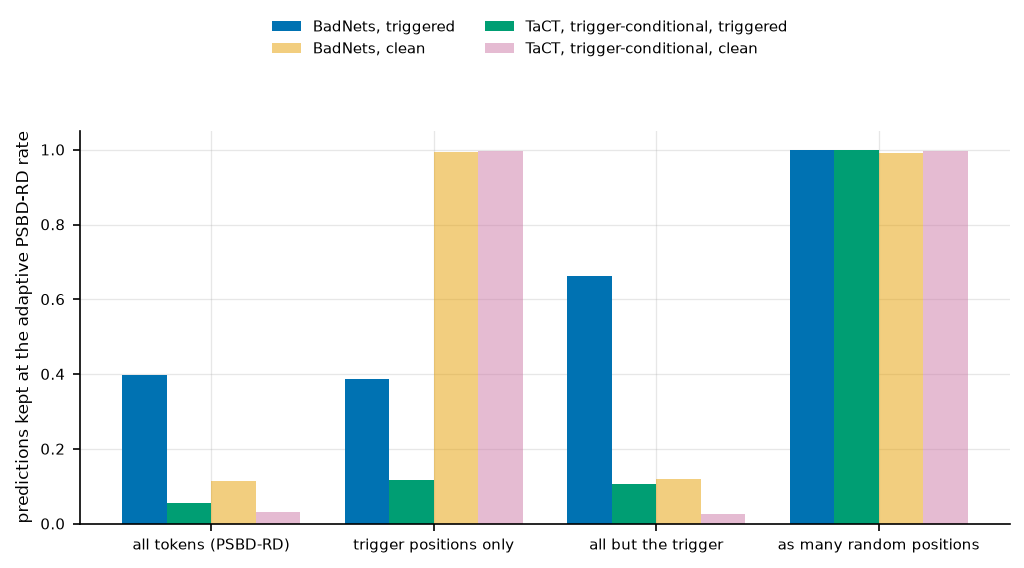

In [16]:
dropout = causal["residual_dropout"]
variants = {"all_tokens": "all tokens (PSBD-RD)", "trigger_only": "trigger positions only", "all_but_trigger": "all but the trigger", "random_same_count": "as many random positions"}
figure, axis = plt.subplots(figsize=(8.0, 3.4))
width = 0.2
positions = np.arange(len(variants))  # (variants,)
for offset, (group, label) in enumerate(list(groups.items())[:2]):
    axis.bar(positions + (offset - 1.5) * width, [dropout[group][v]["triggered_kept"] for v in variants], width=width, label=f"{label}, triggered")
    axis.bar(positions + (offset + 0.5) * width, [dropout[group][v]["clean_kept"] for v in variants], width=width, alpha=0.5, label=f"{label}, clean")
axis.set_xticks(positions, labels=list(variants.values()))
axis.set_ylabel("predictions kept at the adaptive PSBD-RD rate")
legend_above(figure, [axis], columns=2)
plt.show()

assert fmt(dropout["badnet_a2o"]["all_tokens"]["triggered_kept"]) == macro("causal", "CausalRdAllTokens")
assert fmt(dropout["badnet_a2o"]["trigger_only"]["triggered_kept"]) == macro("causal", "CausalRdTriggerOnly")
assert fmt(dropout["badnet_a2o"]["all_but_trigger"]["triggered_kept"]) == macro("causal", "CausalRdAllButTrigger")
rd_bad = dropout["badnet_a2o"]
badnet_models = [m for m in causal["per_model"] if m["group"] == "badnet_a2o"]
per_model_rd_gap = np.mean([abs(m["rd_all_triggered_kept"] - m["rd_trigger_only_triggered_kept"]) for m in badnet_models])
trigger_only_at_least = sum(m["rd_trigger_only_triggered_kept"] <= m["rd_all_triggered_kept"] for m in badnet_models)
tm_ratio = stochastic["badnet_a2o"]["overall"]["triggered_kept"] / stochastic["badnet_a2o"]["overall"]["clean_kept"]
rd_ratio = rd_bad["all_tokens"]["triggered_kept"] / rd_bad["all_tokens"]["clean_kept"]

In [17]:
display(Markdown(rf"""
On BadNets, dropout on the trigger positions alone keeps {rd_bad["trigger_only"]["triggered_kept"]:.3f} of triggered predictions, as few as the library's dropout on all 197 positions ({rd_bad["all_tokens"]["triggered_kept"]:.3f}) in the {len(badnet_models)}-model mean, and dropout on as many random positions keeps {rd_bad["random_same_count"]["triggered_kept"]:.3f}. Per model the 2 differ by {per_model_rd_gap:.3f} on average, and the trigger-only variant breaks at least as much as the library on {trigger_only_at_least} of the {len(badnet_models)} models, so the equality holds for the mean and loosely per model. PSBD-RD corrupts the trigger's stored content on the stream in every block, and that corruption is never repaired because the stream is where the content lives. Dropout on everything but the trigger keeps {rd_bad["all_but_trigger"]["triggered_kept"]:.3f}, so the rest of the stream contributes too. The consequence for detection is that a triggered BadNets prediction is {rd_ratio:.1f} times as likely to survive PSBD-RD as a clean one ({rd_bad["all_tokens"]["triggered_kept"]:.3f} against {rd_bad["all_tokens"]["clean_kept"]:.3f}), against {tm_ratio:.1f} times under PSBD-TM. The figure does not cover global triggers, part D.

Part D keeps a fixed random subset of patch tokens visible at the attention input of all 12 blocks, with keep fraction $f$ running down from 1, and asks how much of the trigger effect survives. **Excess retention** subtracts the share of clean images sent to the target, because a heavily masked ViT collapses onto a default class that is sometimes the target.
"""))


On BadNets, dropout on the trigger positions alone keeps 0.387 of triggered predictions, as few as the library's dropout on all 197 positions (0.398) in the 12-model mean, and dropout on as many random positions keeps 1.000. Per model the 2 differ by 0.223 on average, and the trigger-only variant breaks at least as much as the library on 8 of the 12 models, so the equality holds for the mean and loosely per model. PSBD-RD corrupts the trigger's stored content on the stream in every block, and that corruption is never repaired because the stream is where the content lives. Dropout on everything but the trigger keeps 0.664, so the rest of the stream contributes too. The consequence for detection is that a triggered BadNets prediction is 3.5 times as likely to survive PSBD-RD as a clean one (0.398 against 0.113), against 8.7 times under PSBD-TM. The figure does not cover global triggers, part D.

Part D keeps a fixed random subset of patch tokens visible at the attention input of all 12 blocks, with keep fraction $f$ running down from 1, and asks how much of the trigger effect survives. **Excess retention** subtracts the share of clean images sent to the target, because a heavily masked ViT collapses onto a default class that is sometimes the target.


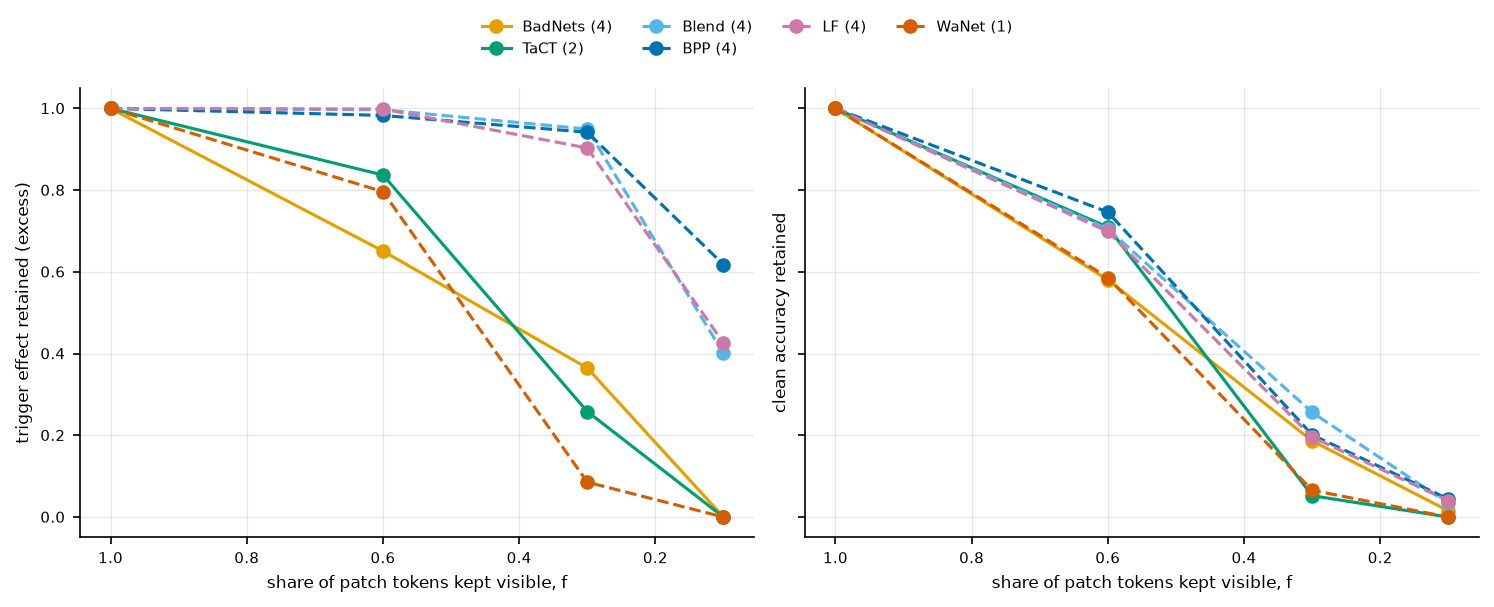

visible-subset readings at f = 0.3 match \CausalVisible*Trigger in paper/tables/causal.macros.json


In [18]:
visible = causal["visible_subsets"]
fractions = ["1.0", "0.6", "0.3", "0.1"]
shown_groups = [group for group in ("badnet_a2o", "tact_trigger_conditional", "blend", "bpp", "lf", "sig", "wanet") if group in visible]
figure, (trigger_axis, clean_axis) = plt.subplots(1, 2, figsize=(10.0, 3.6), sharey=True)
for group in shown_groups:
    color = attack_color(group.removesuffix("_trigger_conditional"))
    label = f"{attack_label(group.removesuffix('_trigger_conditional'))} ({visible[group]['1.0']['models']})"
    style = "-" if group.startswith(("badnet", "tact")) else "--"
    trigger_axis.plot([float(f) for f in fractions], [visible[group][f]["excess_retention"] for f in fractions], marker="o", ls=style, color=color, label=label)
    clean_axis.plot([float(f) for f in fractions], [visible[group][f]["clean_accuracy_retention"] for f in fractions], marker="o", ls=style, color=color)
trigger_axis.set_xlabel("share of patch tokens kept visible, f")
clean_axis.set_xlabel("share of patch tokens kept visible, f")
trigger_axis.set_ylabel("trigger effect retained (excess)")
clean_axis.set_ylabel("clean accuracy retained")
trigger_axis.invert_xaxis()
clean_axis.invert_xaxis()
figure.tight_layout()
legend_above(figure, [trigger_axis], columns=4)
plt.show()
for attack in ("Blend", "Bpp", "Lf", "Sig", "Wanet"):
    group = attack.lower()
    shown = f"{visible[group]['0.3']['excess_retention']:.2f}" if group in visible else "--"
    assert shown == macro("causal", f"CausalVisible{attack}Trigger"), attack
print("visible-subset readings at f = 0.3 match \\CausalVisible*Trigger in paper/tables/causal.macros.json")
global_groups = [group for group in ("blend", "bpp", "lf", "sig") if group in visible]
global_words = word_list([attack_label(group) for group in global_groups])
global_trigger_kept = [visible[g]["0.3"]["excess_retention"] for g in global_groups]
global_clean_kept = [visible[g]["0.3"]["clean_accuracy_retention"] for g in global_groups]
wanet_trigger_kept = visible["wanet"]["0.3"]["excess_retention"]
wanet_clean_kept = visible["wanet"]["0.3"]["clean_accuracy_retention"]
hidden = causal["visible_subsets_patch_by_trigger_visibility"]
hidden_retention = sorted({round(hidden[f]["trigger_hidden"]["excess_retention"], 3) for f in hidden if "trigger_hidden" in hidden[f]})

In [19]:
display(Markdown(rf"""
Solid lines are the patch triggers, dashed the global ones. With 30% of tokens visible {global_words} keep {min(global_trigger_kept):.2f} to {max(global_trigger_kept):.2f} of their trigger effect while clean accuracy keeps only {min(global_clean_kept):.2f} to {max(global_clean_kept):.2f} (`\CausalVisibleGlobalTriggerMin` to `Max`), so a global trigger stays legible from almost any subset of tokens, and that is why every placement detects it. WaNet keeps {wanet_trigger_kept:.2f} of its trigger against {wanet_clean_kept:.2f} of its clean accuracy, the 1 global trigger that behaves like content, which is why token masking has no edge on WaNet. BadNets retains more trigger than clean accuracy only while some trigger token stays visible, and on the patch models the draws that hid every trigger token retain {word_list([f"{v:.3f}" for v in hidden_retention])}. The subsets are fixed across blocks here, unlike PSBD-TM's per-block draws, so this part measures legibility, not the detector.
"""))


Solid lines are the patch triggers, dashed the global ones. With 30% of tokens visible Blend, BPP and LF keep 0.90 to 0.95 of their trigger effect while clean accuracy keeps only 0.20 to 0.26 (`\CausalVisibleGlobalTriggerMin` to `Max`), so a global trigger stays legible from almost any subset of tokens, and that is why every placement detects it. WaNet keeps 0.09 of its trigger against 0.07 of its clean accuracy, the 1 global trigger that behaves like content, which is why token masking has no edge on WaNet. BadNets retains more trigger than clean accuracy only while some trigger token stays visible, and on the patch models the draws that hid every trigger token retain 0.000. The subsets are fixed across blocks here, unlike PSBD-TM's per-block draws, so this part measures legibility, not the detector.


## 6. Why masking beats noise at the same position

`placement-walk.ipynb` found Gaussian noise at the attention input far below token masking at the same position at the matched rule (`\GaussianMinusTokenMaskAttentionNorm`), while after the MLP norm noise does well. The position `before_attention_norm` feeds a LayerNorm, which subtracts each token's mean and divides by its standard deviation. Additive noise inflates that standard deviation, so the division shrinks the noise back. Zeroing a token removes content that no rescaling restores. `experiments/residual_stream_mechanism/layernorm_absorption.py` measures this on real activations: inject a perturbation of relative size $r_{in} = \lVert x' - x\rVert/\lVert x\rVert$, and compare it with the relative change after the LayerNorm, $r_{out} = \lVert \mathrm{LN}(x') - \mathrm{LN}(x)\rVert / \lVert \mathrm{LN}(x)\rVert$. **Survival** is $r_{out}/r_{in}$, 1 when the norm passes the perturbation through. The cell reads the record, per injected size on the left and averaged on the right.

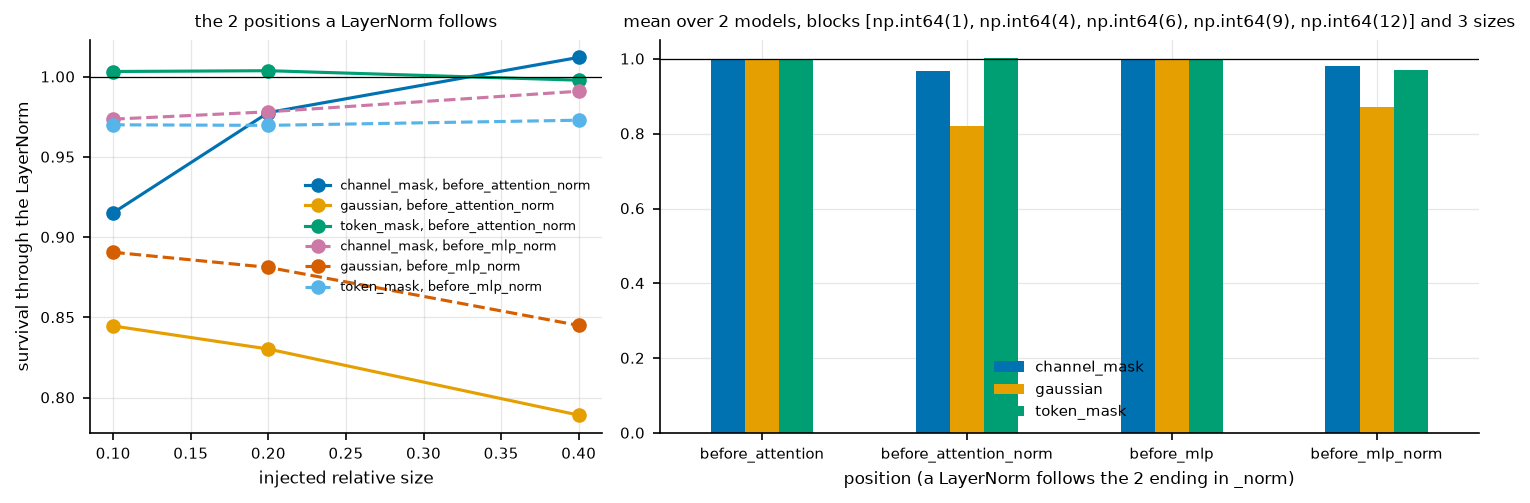

operator,channel_mask,gaussian,token_mask
position,,,
before_attention,1.000,1.000,1.000
before_attention_norm,0.968,0.821,1.002
before_mlp,1.000,1.000,1.000
before_mlp_norm,0.981,0.872,0.971


In [20]:
real_rows = []
for path in sorted(glob.glob("results/*/layernorm_absorption.json")):
    record = load_json(path)
    for row in record["rows"]:
        real_rows.append({"model": record["folder_name"], **row})
real = pd.DataFrame(real_rows)
real_survival = real.groupby(["position", "operator"])["survival"].mean().unstack()  # (positions, operators)
by_target = real[real["normalised"]].groupby(["position", "operator", "target"])["survival"].mean()  # (position, operator, target)

figure, (target_axis, real_axis) = plt.subplots(1, 2, figsize=(10.0, 3.4), gridspec_kw={"width_ratios": [1, 1.6]})
for (position, operator), rows in by_target.groupby(level=[0, 1]):
    target_axis.plot(rows.index.get_level_values("target"), rows.values, marker="o", ls="-" if position == "before_attention_norm" else "--", label=f"{operator}, {position}")
target_axis.axhline(1, color="black", lw=0.6)
target_axis.set_xlabel("injected relative size")
target_axis.set_ylabel("survival through the LayerNorm")
target_axis.set_title("the 2 positions a LayerNorm follows", fontsize=8)
target_axis.legend(fontsize=6)
real_survival.plot.bar(ax=real_axis, rot=0)
real_axis.axhline(1, color="black", lw=0.6)
real_axis.set_title(f"mean over {real['model'].nunique()} models, blocks {sorted(real['block'].unique())} and 3 sizes", fontsize=8)
real_axis.set_xlabel("position (a LayerNorm follows the 2 ending in _norm)")
real_axis.legend()
figure.tight_layout()
plt.show()

assert fmt(real_survival.loc["before_attention_norm", "gaussian"]) == macro("layernorm_absorption", "AbsorptionAttentionInputGaussianSurvival")
assert fmt(real_survival.loc["before_attention_norm", "token_mask"]) == macro("layernorm_absorption", "AbsorptionAttentionInputTokenMaskSurvival")
real_models = sorted(real["model"].unique())
gaussian_by_size = by_target.loc[("before_attention_norm", "gaussian")]
real_survival.round(3)

In [21]:
display(Markdown(rf"""
The LayerNorm passes token masking through at a survival of {real_survival.loc["before_attention_norm", "token_mask"]:.3f} at the attention input (`\AbsorptionAttentionInputTokenMaskSurvival`) and absorbs part of Gaussian noise ({real_survival.loc["before_attention_norm", "gaussian"]:.3f} survives), and the absorption {"grows" if gaussian_by_size.is_monotonic_decreasing else "varies"} with the injected size, from {gaussian_by_size.iloc[0]:.3f} surviving at the smallest size to {gaussian_by_size.iloc[-1]:.3f} at the largest. At the 2 positions no LayerNorm follows, `before_attention` and `before_mlp`, every operator survives at {real_survival.loc[["before_attention", "before_mlp"]].min().min():.3f} or more, the control. So noise at the attention input is weaker than its nominal size, and it needs a larger rate to reach the same shift ratio, which spends its disturbance on content rather than on removing tokens. The record covers {len(real_models)} models ({word_list([f"`{m}`" for m in real_models])}), and the absorption explains part of the noise deficit, not the whole of token masking's edge over dropout and channel masking, which also pass through the norm (channel masking survives at {real_survival.loc["before_attention_norm", "channel_mask"]:.3f}).
"""))


The LayerNorm passes token masking through at a survival of 1.002 at the attention input (`\AbsorptionAttentionInputTokenMaskSurvival`) and absorbs part of Gaussian noise (0.821 survives), and the absorption grows with the injected size, from 0.845 surviving at the smallest size to 0.789 at the largest. At the 2 positions no LayerNorm follows, `before_attention` and `before_mlp`, every operator survives at 1.000 or more, the control. So noise at the attention input is weaker than its nominal size, and it needs a larger rate to reach the same shift ratio, which spends its disturbance on content rather than on removing tokens. The record covers 2 models (`vit_cifar100_blend_0_05` and `vit_gtsrb_badnet_a2o_0_1`), and the absorption explains part of the noise deficit, not the whole of token masking's edge over dropout and channel masking, which also pass through the norm (channel masking survives at 0.968).


## What this means for the placement

A patch trigger's evidence lives in its own few tokens of the residual stream and is read by the class token in the late blocks. The backdoor itself is a direction the class token acquires in those blocks. Token masking at the attention input hides a token from 1 attention read and leaves the stream intact, so the triggered prediction keeps most of its strength while at least 1 trigger token is read intact in the late blocks and weakens gradually as more of those reads are hidden (survival 0.987 down to 0.216 over the number of fully hidden late blocks, `docs/why-psbd-works-theory.md`), while a clean prediction, which needs many tokens, falls apart. `why-psbd-tm.ipynb` measures this on the current panel, on Swin as well, and tests the explanations that fail. That gap is the PSU separation. Residual dropout corrupts the stored trigger content itself, so triggered predictions break more often and PSU separates less. A global trigger is legible from any subset of tokens and survives both operators, which is why the 2 placements tie there. WaNet behaves like content under token masking, and PSBD-RD detects it better. `depth-bands.ipynb` finds that every 4-block band of PSBD-TM loses to all 12 blocks on the panel, with the best band differing from attack to attack, so the mask has to act at every depth rather than only where BadNets is read. The open questions this leaves, including the SIG model and Swin, are listed in `docs/open-questions.md`.